In [2]:
!pip install -q seaborn
import docker.work.latent_analysis.helpers.helpers_latent as helperLatent
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Using Docker as the Jupyter kernel

Make sure Jupyter is running inside the Docker container, so notebooks use the Docker environment.

Edit the run script to:

#!/bin/sh
docker run --rm -it -p 8888:8888 \
  -v $(pwd)/work:/home/renaissance/work \
  -v $(pwd)/..:/renaissance \
  -v $(pwd)/../../smolfem:/smolfem \
  renaissance_docker


Then start the container and launch Jupyter:

cd docker
./run
jupyter notebook --ip=0.0.0.0 --port=8888 --no-browser --allow-root


Use the printed URL to connect as an existing Jupyter server (e.g. from VS Code).

# Training Results

To train the generator you need to `run 1-renaissance.py` with the right parameters. See `latent_analysis/latent_config.ini` for the ones that were used for this model.


Incidence Generator 40: 5.00%
Incidence Generator 62: 15.00%
Incidence Generator 94: 23.00%


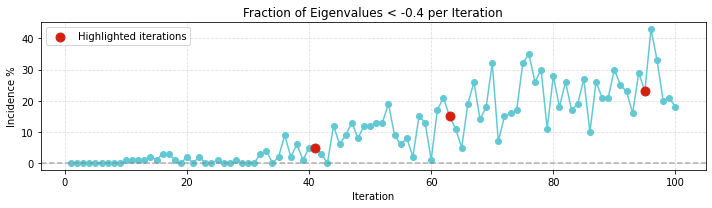

In [ ]:

df = pd.read_csv("latent_analysis/output/km-18to2_decay99/training/eigenvalue_log.csv")


incidences = helperLatent.get_incidence_at_training(df)
highlight_iters = [40, 62, 94]
fig = helperLatent.plot_training_incidence(incidences, highlight_iters)

fig_name = "TRAINING_generator.svg"
fig_path = 'latent_analysis/output/km-18to2_decay99/plots/final/' + fig_name
fig.savefig(
    fig_path,
    bbox_inches="tight"
)

# Sampling

To sample parameter sets from the chosen generators, run `latent_analysis/2-load_and_generate_latent.py`.  
Unlike `2-load_and_generate.py` in the project root, this script saves the scaled, unscaled, and latent feature vectors, which are required for the analyses in this section.


## Distribution of max eigenvalues for select generators

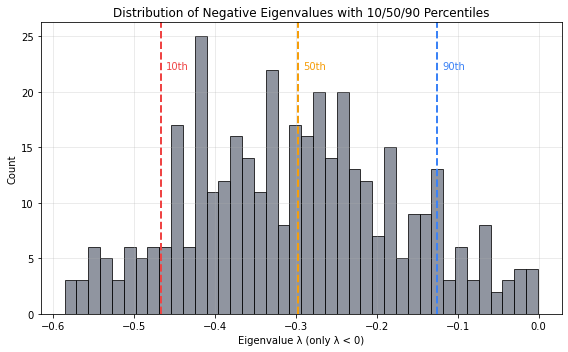

In [ ]:
training_iteration = 62 # index of generator you want to look at

path = (
    f"latent_analysis/output/km-18to2_decay99/sampling/iter{training_iteration}/samples/"
    "500_sampled_params_max_eig.csv"
)
colors = {
    "hist": "#6B7280",   # slate gray
    10: "#EF4444",       # soft red
    50: "#F59E0B",       # amber
    90: "#3B82F6",       # soft blue
}

fig, percentiles = helperLatent.plot_negative_eigenvalue_distribution(path, colors = colors, offset = -0.035) # for some histograms the text is on a bar and you cant read it. Try offsets from -0.05 to +0.05

fig.savefig(
    f"latent_analysis/output/km-18to2_decay99/plots/final"
    f"EIG_DIST_iter{training_iteration}.svg",
    bbox_inches="tight"
)

plt.show()

## Get 3 points closest to the 10/50/90th percentile

- Note that for gen62 we chose the second closest point (index 191) to the 90th percentile, as the first (with index 27) became unstable due to scaling artifacts.

In [ ]:
import docker.work.latent_analysis.helpers.helpers_latent as helperLatent
iters = [94, 62, 40]

for it in iters:

    if it == 94:                 # look, I know this is an odd workaround, but I didn't have time yet to make sure all csvs have headers.
        csv_has_header=True
    else: 
        csv_has_header=False

    max_eigenvalues_path = f"latent_analysis/output/km-18to2_decay99/sampling/iter{it}/samples/500_sampled_params_max_eig.csv"
    result = helperLatent.get_3_percentile_latent_vectors_info(
        max_eigenvalues_path,
        csv_has_header=csv_has_header,    # important! You might need to set this to True depending on your CSV file
        threshold=0
    )
    print(f"iter{it} → {result}")

iter94 →    percentile  target_value  selected_index  selected_eigenvalue
0          10     -0.668419             341            -0.667219
1          50     -0.364737             495            -0.364933
2          90     -0.106993             167            -0.107182
iter62 →    percentile  target_value  selected_index  selected_eigenvalue
0          10     -0.467134             213            -0.466911
1          50     -0.297646             147            -0.296835
2          90     -0.125197             397            -0.125942
iter40 →    percentile  target_value  selected_index  selected_eigenvalue
0          10     -0.363434             496            -0.363434
1          50     -0.211659             407            -0.211659
2          90     -0.063172             288            -0.063172


# Perturbation Study

run `latent_analysis/6-latent_analysis-pipeline.py` with selected generator and indices of points you are interested in defined in `latent_config.ini`, and the script will run individual perturbation, select 2 most relevant features and perform joint perturbation analysis on these. All scaling is done in the background.

*Note on parameter scaling*


- When we generated 500 parameter sets, the code automatically saved the latent vectors used and their corresponding maximum eigenvalues.
- These eigenvalues were computed after batch-scaling all 500 parameter sets together, so that the resulting Km values fit within physiological ranges taken from BRENDA. <br>


- For the latent-space perturbation analysis, every perturbed parameter set must be compared to its baseline.
- To do this correctly, the perturbed parameter sets must be scaled together with the original 500 samples.
- Scaling only the ~99 perturbed samples would distort the range, because this smaller set does not represent the full Km distribution.<br>


- As a result, the baseline eigenvalue used in latent-space analysis may differ slightly from the original eigenvalue stored during sampling.
- This difference comes from re-scaling the original sample together with the perturbed samples, which changes the scaling bounds.<br>

## Results Dashboard

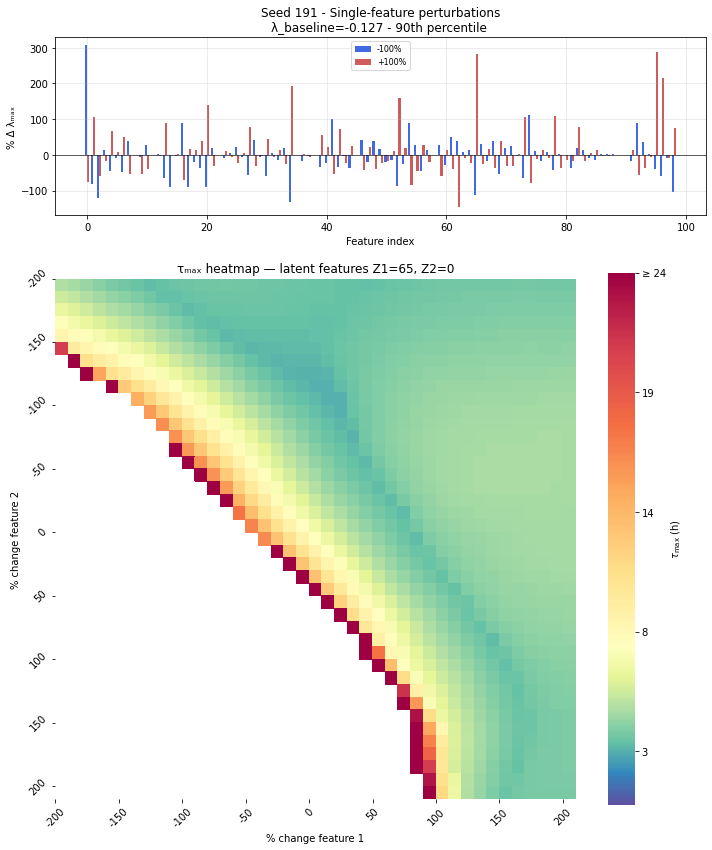

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import docker.work.latent_analysis.helpers.helpers_latent as helperLatent

root = 'latent_analysis/output/km-18to2_decay99/3_point_analysis/run_6'
path_dict = helperLatent.parse_generators(root)

# generator_ids = [40, 62, 94]
   
#seed_latent_vectors = [

#        [496, 407, 288], # 40s
#        [366, 265, 191],  # 62
#        [341, 495, 167], # 94

gen_id = 62
point_id = 191
pct = 90
tau_cutoff = 24

plot = helperLatent.plot_one_point(path_dict, gen_id=gen_id, point_id=point_id, percentile = pct, centered_colorscale=True, tau_cutoff = tau_cutoff)

fig_name = f"DASHBOARD_gen{gen_id}_seed{point_id}.svg"
fig_path = 'latent_analysis/output/km-18to2_decay99/plots/final/' + fig_name
plot.savefig(
    fig_path,
    bbox_inches="tight"
)

## Just the heatmap



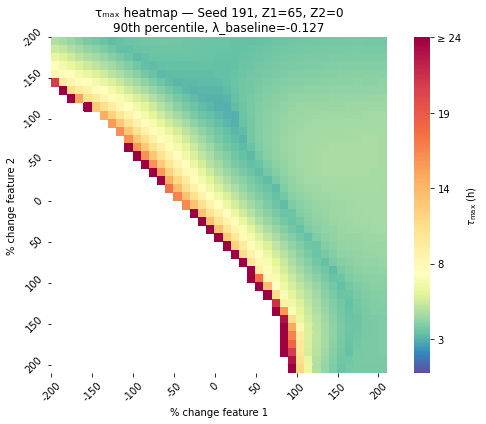

In [7]:
# generator_ids = [40, 62, 94]
   
#seed_latent_vectors = [

#        [496, 407, 288], # 40s
#        [366, 265, 191],  # 62
#        [341, 495, 167], # 94

gen_id = 62
point_id = 191
percentile = 90
tau = 24
fig = helperLatent.plot_one_point_heatmap(
    path_dict,
    gen_id=gen_id,
    point_id=point_id,
    percentile=percentile,
    centered_colorscale=True,
    tau_cutoff=tau
)

out_dir = "latent_analysis/output/km-18to2_decay99/plots/final"

fig.savefig(
    f"{out_dir}/HEATMAP_gen{gen_id}_point{point_id}_pct{percentile}.svg",
    bbox_inches="tight"
)

plt.show() 



## Sanity Checks

The values obtained from individual perturbations of the two most relevant features should match the corresponding values from the joint perturbation at the points (0, 0), (+100, 0), (−100, 0), (0, +100), and (0, −100).

In [8]:
seed_latent_vectors = [
        [495, 406, 287],  # 40
        [212, 146, 191],  # 62
        [341, 495, 167],  # 94
    ]

root = 'latent_analysis/output/km-18to2_decay99/3_point_analysis/run_6'
path_dict = helperLatent.parse_generators(root)
helperLatent.sanity_check_individual_vs_joint(path_dict, 62, 191)

====== SANITY CHECK: Joint vs Individual ======
Generator 62 with seed point 191
Top2 features: f1=65, f2=0
Baseline λ (grid center)of joint: -0.127591
Baseline λ (for individual pert): -0.127325

lambda_grid[i_plus, i0]:  0.23129220645499055
pc_plus[f1]:  281.65507111694757
f1 +100%:
  Joint:      281.276 %
  Individual: 281.655 %

f1 -100%:
  Joint:      -110.830 %
  Individual: -111.271 %

f2 +100%:
  Joint:      -74.956 %
  Individual: -75.322 %

f2 -100%:
  Joint:      306.021 %
  Individual: 306.452 %
